In [3]:
# this path append is for binder only
import sys
sys.path.append("../../")

#spectrome modules
from spectrome.utils import functions, path
from spectrome.brain import Brain

from spectrome.forward import ntf_local_stimulus as nt_stim
from spectrome.forward import ntf_local as nt_nostim
from spectrome.forward import ntf_local_stimulus as nt_stim

#generic modules
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import pickle as pkl
from scipy import stats
from scipy.io import loadmat
from scipy.stats import pearsonr, spearmanr
from scipy.io import savemat


# from fooof import FOOOF
from fooof.plts.annotate import plot_annotated_model

from statsmodels.stats.multicomp import MultiComparison
import statsmodels.stats
import statsmodels.api as sm
from statsmodels.stats import weightstats
from statsmodels.stats.multitest import fdrcorrection
import pingouin as pg
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import mannwhitneyu

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [1]:
# !pip install "pandas==1.5.3"

In [2]:
##all the sessions data of MEG
data1=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess1.mat")
data2=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess2.mat")
data3=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess3.mat")
data4=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess4.mat")


##all the sessions mi 
sess1_mi_avg=data1['Avg_MI_MEG_DK']
sess2_mi_avg=data2['Avg_MI_MEG_DK']
sess3_mi_avg=data3['Avg_MI_MEG_DK']
sess4_mi_avg=data4['Avg_MI_EEG_DK']

##all the sessions resting state
sess1_rest_avg=data1['Avg_RS1_MEG_DK']
sess2_rest_avg=data2['Avg_RS1_MEG_DK']
sess3_rest_avg=data3['Avg_RS1_MEG_DK']
sess4_rest_avg=data4['Avg_RS1_EEG_DK']

##all the sessions baseline
sess1_base_avg=data1['Avg_Baseline_MEG_DK']
sess2_base_avg=data2['Avg_Baseline_MEG_DK']
sess3_base_avg=data3['Avg_Baseline_MEG_DK']
sess4_base_avg=data4['Avg_Baseline_EEG_DK']

In [3]:
##modeled data-MEG
x_mi_all={}
x_base_all={}
x_rest_all={}

for num in range(1, 5):
    x_mi_all[num]=np.zeros((68, 10, 19))
    x_base_all[num]=np.zeros((68, 10, 19))
    x_rest_all[num]=np.zeros((68, 10, 19))
    
    for i in range(19):
        mi_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/mi_allsubs_f/mi_nostim_mse_db_fvec330_{i}.p'
        with open(mi_fname, 'rb') as f:
            x_mi_all[num][:,:,i]=np.array(pkl.load(f))

        base_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/baseline_allsubs_f/baseline_nostim_mse_db_fvec330_{i}.p'
        with open(base_fname, 'rb') as f:
            x_base_all[num][:,:,i] = np.array(pkl.load(f))

        rest_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/rs1_allsubs_f0/rs1_nostim_mse_db_fvec330_{i}.p'
        with open(rest_fname, 'rb') as f:
            x_rest_all[num][:,:,i]=np.array(pkl.load(f))
  

In [4]:
## Load all the regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
##targeted frequency range
fvec = np.squeeze(data1["Freqs"])[3:30]

In [5]:
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'])

In [6]:
# All regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    print(i, r['ROI'].strip("'"))
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

0 bankssts L
1 bankssts R
2 caudalanteriorcingulate L
3 caudalanteriorcingulate R
4 caudalmiddlefrontal L
5 caudalmiddlefrontal R
6 cuneus L
7 cuneus R
8 entorhinal L
9 entorhinal R
10 frontalpole L
11 frontalpole R
12 fusiform L
13 fusiform R
14 inferiorparietal L
15 inferiorparietal R
16 inferiortemporal L
17 inferiortemporal R
18 insula L
19 insula R
20 isthmuscingulate L
21 isthmuscingulate R
22 lateraloccipital L
23 lateraloccipital R
24 lateralorbitofrontal L
25 lateralorbitofrontal R
26 lingual L
27 lingual R
28 medialorbitofrontal L
29 medialorbitofrontal R
30 middletemporal L
31 middletemporal R
32 paracentral L
33 paracentral R
34 parahippocampal L
35 parahippocampal R
36 parsopercularis L
37 parsopercularis R
38 parsorbitalis L
39 parsorbitalis R
40 parstriangularis L
41 parstriangularis R
42 pericalcarine L
43 pericalcarine R
44 postcentral L
45 postcentral R
46 posteriorcingulate L
47 posteriorcingulate R
48 precentral L
49 precentral R
50 precuneus L
51 precuneus R
52 ros

In [7]:
alpha_band = (8, 12)
beta_band  = (13, 30)


In [8]:
def band_idx(freqs, band):
    return np.where((freqs >= band[0]) & (freqs <= band[1]))[0]


In [9]:
# def compute_erd(mi, rs, freqs, band):
#     idx = band_idx(freqs, band)
#     p_mi = mi[..., idx].mean(axis=-1)
#     # print("p_mi min:", p_mi.min())
#     # print("p_mi median:", np.median(p_mi))

#     p_rs = rs[..., idx].mean(axis=-1)
#     # print("p_rs min:", p_rs.min())
#     # print("p_rs median:", np.median(p_rs))
#     erd = 100 * (p_mi - p_rs) / p_rs
#     return erd  # shape: (subjects, ROIs)

# # print("p_rs min:", p_rs.min())
# # print("p_rs median:", np.median(p_rs))


In [10]:
def compute_erd(mi, rs, freqs, band):
    idx = band_idx(freqs, band)
    p_mi = mi[..., idx].mean(axis=-1)
    p_rs = rs[..., idx].mean(axis=-1)

    erd = 10*np.log10((p_mi) / (p_rs))
    return erd


In [11]:
sessions = {
    1: (sess1_mi_avg, sess1_rest_avg),
    2: (sess2_mi_avg, sess2_rest_avg),
    3: (sess3_mi_avg, sess3_rest_avg),
    4: (sess4_mi_avg, sess4_rest_avg),
}

erd_alpha = {}
erd_beta  = {}


for s, (mi, rs) in sessions.items():
    erd_alpha[s] = compute_erd(mi, rs, fvec, alpha_band)
    erd_beta[s]  = compute_erd(mi, rs, fvec, beta_band)


In [12]:
##combining alpha and beta ERD
erd_ab = {}
for s in sessions:
    erd_ab[s] = 0.5 * erd_alpha[s] + 0.5 * erd_beta[s]


In [13]:
erd_ab[4].shape

(19, 68)

In [14]:
erd_roi = {}
for s in erd_ab:
    erd_roi[s] = np.median(erd_ab[s], axis=0)  # shape (68,)


In [15]:
#Find the regions coresponding to negative ERD 
regions_list = {}
for s in erd_roi:
    # print(f"Session {s}:")
    idx = np.where(erd_roi[s] < 0)[0]
    region = [all_regions[i].strip(" '' ") for i in idx]
    regions_list[s] = region
   
len(regions_list[4])

37

## taue

In [16]:
# shape: (19, 68)
delta_taue = {} 
for s in range(1, 5):
    taue_mi = x_mi_all[s][:, 2, :] / x_rest_all[s][:, 2, :] - 1
    delta_taue[s] = taue_mi.T

#for each region
delta_taue_roi = {}
for s in delta_taue:
    delta_taue_roi[s] = np.median(delta_taue[s], axis=0)

In [17]:
delta_taue[1].shape, delta_taue_roi[1].shape

((19, 68), (68,))

In [18]:
# #Find the regions that shows positive and negative change in TAUE
# negative_taue_regions = {}
# positive_taue_regions = {}
# for s in delta_taue_roi:
#     # print(f"Session {s}:")
#     idx_pos = np.where(delta_taue_roi[s] >= 0)[0]
#     idx_neg = np.where(delta_taue_roi[s] < 0)[0]
#     region_pos = [all_regions[i].strip(" '' ") for i in idx_pos]
#     region_neg = [all_regions[i].strip(" '' ") for i in idx_neg]
#     negative_taue_regions[s] = region_neg
#     positive_taue_regions[s] = region_pos



In [19]:
## correlation between ERD and delta taue - spearman correlation
erd_taue_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_taue_roi[s])
    erd_taue_corr[s] = {"rho": rho, "p": p}

for s in erd_taue_corr:
    print(f"Session {s}: Spearman rho={erd_taue_corr[s]['rho']:.3f}, "
          f"p={erd_taue_corr[s]['p']:.8f}")


Session 1: Spearman rho=0.551, p=0.00000115
Session 2: Spearman rho=0.458, p=0.00008710
Session 3: Spearman rho=0.493, p=0.00001960
Session 4: Spearman rho=0.417, p=0.00040671


In [49]:
# Repeated measures correlation
# dataframe for all sessions, subjects, regions

n_regions = 68
n_subjects = 19
sessions = [1, 2, 3, 4]

records = []

for sess in sessions:
    mi_data = x_mi_all[sess][:, 2, :]       # (68, 19)
    rest_data = x_rest_all[sess][:, 2, :]   # (68, 19)
    erd_data = erd_ab[sess]                 # (19, 68)

    for subj_idx in range(n_subjects):
        row = {
            "Subject": f"Subj_{subj_idx+1}",
            "Session": sess
        }

        for roi in range(n_regions):
            row[f"ERD_ROI{roi}"] = erd_data[subj_idx, roi]
            row[f"Taue_Diff_ROI{roi}"] = (
                mi_data[roi, subj_idx] / rest_data[roi, subj_idx] - 1
            )

        records.append(row)

df_all = pd.DataFrame(records)

print(f"Dataframe prepared. Shape: {df_all.shape} "
      f"(Rows: {n_subjects*len(sessions)}, Cols: ERD + τe)")


Dataframe prepared. Shape: (76, 138) (Rows: 76, Cols: ERD + τe)


In [50]:
n_regions = 68
n_subjects = 19
sessions = [1, 2, 3, 4]

records = []

for sess in sessions:
    mi_data = x_mi_all[sess][:, 2, :]       # (68, 19)
    rest_data = x_rest_all[sess][:, 2, :]   # (68, 19)
    erd_data = erd_ab[sess]                 # (19, 68)

    for subj_idx in range(n_subjects):
        row = {
            "Subject": f"Subj_{subj_idx+1}",
            "Session": sess
        }

        for roi in range(n_regions):
            row[f"ERD_ROI{roi}"] = erd_data[subj_idx, roi]
            row[f"Taue_Diff_ROI{roi}"] = (
                mi_data[roi, subj_idx] / rest_data[roi, subj_idx] - 1
            )

        records.append(row)

df_all = pd.DataFrame(records)

print(f"Dataframe prepared. Shape: {df_all.shape} "
      f"(Rows: {n_subjects*len(sessions)}, Cols: ERD + τe)")


Dataframe prepared. Shape: (76, 138) (Rows: 76, Cols: ERD + τe)


In [51]:
df_all

,Subject,Session,ERD_ROI0,Taue_Diff_ROI0,ERD_ROI1,Taue_Diff_ROI1,ERD_ROI2,Taue_Diff_ROI2,ERD_ROI3,Taue_Diff_ROI3,...,ERD_ROI63,Taue_Diff_ROI63,ERD_ROI64,Taue_Diff_ROI64,ERD_ROI65,Taue_Diff_ROI65,ERD_ROI66,Taue_Diff_ROI66,ERD_ROI67,Taue_Diff_ROI67
0,Subj_1,1,1.237586,-0.140477,-0.596909,-0.063183,0.069754,-0.000245,-0.163784,0.019738,...,-1.456133,-0.096337,1.572769,-0.125259,2.307161,-0.605473,0.745937,-0.056163,-0.398687,-0.104681
1,Subj_2,1,0.992611,-0.176195,-0.609178,1.206894,0.239483,-0.721182,1.043304,-0.604067,...,1.022276,-0.832816,-0.598077,0.000000,1.316147,0.000000,0.348638,-0.091554,-0.254057,-0.633674
2,Subj_3,1,-3.427769,-0.506796,-0.926492,-0.495950,0.849447,-0.461609,-1.651089,-0.548130,...,-2.925416,-0.458044,0.039456,-0.202296,1.259191,-0.240048,-3.054757,-0.512589,-1.365997,-0.419593
3,Subj_4,1,-3.223162,-0.490476,-2.159013,-0.506900,0.168454,-0.048867,-0.068684,0.008433,...,-0.664215,-0.384630,-0.100112,-0.505165,1.397391,-0.592431,-0.717948,-0.471520,-0.531054,-0.554551
4,Subj_5,1,-2.569079,-0.250592,-0.636554,-0.216652,-1.004179,-0.238569,-1.772997,-0.226280,...,-0.765646,-0.305633,-2.821851,-0.086143,0.930814,-0.183664,-2.537175,-0.206834,-2.696340,-0.203819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Subj_15,4,0.478667,0.035529,-0.719593,-0.157608,1.292121,-0.174394,1.724685,-0.279706,...,0.531040,-0.156203,4.283520,0.264528,0.381160,-0.399805,0.973372,0.129001,0.218502,-0.028052
72,Subj_16,4,-0.068933,-0.292922,0.854284,-0.286310,0.351603,0.006506,-0.068169,0.169342,...,-0.053034,-0.104504,6.608638,0.054885,5.167488,-0.115368,0.383846,-0.103553,0.660496,0.010926
73,Subj_17,4,-0.084093,-0.090949,-1.008271,0.166281,2.513411,0.301491,0.777956,0.429756,...,-0.458432,0.075757,-0.231153,0.609280,1.023949,0.168456,-0.964861,-0.350793,-1.862818,0.141229
74,Subj_18,4,0.169007,-0.014439,-3.979546,0.166258,0.165974,-0.085072,0.207828,-0.196595,...,-3.060923,-0.105419,2.059212,-0.458067,0.752669,-0.833333,0.099152,0.165607,-2.603941,-0.174557


In [52]:
##repeated measure correlation
import pingouin as pg

long_records = []

for roi in range(n_regions):
    for _, row in df_all.iterrows():
        long_records.append({
            "Subject": row["Subject"],
            "Session": row["Session"],
            "ROI": roi,
            "ERD": row[f"ERD_ROI{roi}"],
            "Taue_Diff": row[f"Taue_Diff_ROI{roi}"]
        })

df_long = pd.DataFrame(long_records)


rmcorr_results = []

for roi in range(n_regions):
    df_roi = df_long[df_long["ROI"] == roi]

    rmc = pg.rm_corr(
        data=df_roi,
        x="Taue_Diff",
        y="ERD",
        subject="Subject"
    )

    rmcorr_results.append({
        "ROI": roi,
        "r": rmc["r"].values[0],
        "p_uncorrected": rmc["pval"].values[0]
    })

df_rmcorr = pd.DataFrame(rmcorr_results)

from statsmodels.stats.multitest import fdrcorrection

rej, p_fdr = fdrcorrection(df_rmcorr["p_uncorrected"], alpha=0.05)

df_rmcorr["p_fdr"] = p_fdr
df_rmcorr["significant"] = rej


In [53]:
df_rmcorr["r"].min(), df_rmcorr["r"].max()

(-0.5054371323721846, 0.5765901857465332)

In [54]:
#all r values of df_rmcorr
r_values = df_rmcorr["r"].values
r_values

array([ 0.18378152, -0.09684795,  0.07139455, -0.09324036, -0.09675131,
        0.04178892, -0.35729973, -0.50543713,  0.19833179, -0.24771617,
        0.01330401, -0.12259494, -0.08146905,  0.35850574,  0.01568806,
        0.24947454, -0.02094162, -0.07364513, -0.15942198, -0.05389847,
       -0.05971691, -0.17471788, -0.18196281, -0.23225917, -0.2841138 ,
       -0.01753842, -0.02795914, -0.2957975 , -0.15671219, -0.18480304,
        0.17512985, -0.0946226 , -0.08679169,  0.01792028,  0.00544385,
        0.32984317, -0.14632009,  0.00763954, -0.07097376,  0.01462325,
       -0.04125052,  0.01927572, -0.45205995, -0.39747824, -0.05802991,
        0.20750168,  0.14813964, -0.25385297,  0.13810692, -0.01168416,
       -0.17832841, -0.32496979,  0.03169736,  0.01739983, -0.15595043,
       -0.0385448 ,  0.04325555, -0.12535835,  0.57659019,  0.41737562,
        0.28431533, -0.04468784,  0.33149681,  0.31912734, -0.08176387,
        0.09822728, -0.32248495,  0.2938409 ])

In [55]:
# Find regions with significant repeated measures correlation and store in a list
significant_regions = df_rmcorr[df_rmcorr["significant"]].sort_values("p_fdr")
significant_regions_list = significant_regions["ROI"].tolist()
print(significant_regions_list)

for roi in significant_regions_list:
    r = df_rmcorr.loc[df_rmcorr["ROI"] == roi, "r"].values[0]
    p = df_rmcorr.loc[df_rmcorr["ROI"] == roi, "p_fdr"].values[0]
    print(f"{all_regions[roi]}, r = {r:.3f},  p_FDR = {p:.8f}")

[58, 7, 42, 59, 43]
superiorparietal L, r = 0.577,  p_FDR = 0.00014758
cuneus R, r = -0.505,  p_FDR = 0.00176530
pericalcarine L, r = -0.452,  p_FDR = 0.00833115
superiorparietal R, r = 0.417,  p_FDR = 0.01896707
pericalcarine R, r = -0.397,  p_FDR = 0.02725961


### Paper Figure

In [56]:
df_roi = df_long[df_long["ROI"] == 58]
df_roi

,Subject,Session,ROI,ERD,Taue_Diff
4408,Subj_1,1,58,-0.955434,-0.037301
4409,Subj_2,1,58,3.592268,-0.026123
4410,Subj_3,1,58,-6.403800,-0.099313
4411,Subj_4,1,58,-3.559215,-0.416881
4412,Subj_5,1,58,-4.981725,-0.088443
...,...,...,...,...,...
4479,Subj_15,4,58,1.157653,-0.492286
4480,Subj_16,4,58,0.301182,0.128071
4481,Subj_17,4,58,-1.163191,-0.033799
4482,Subj_18,4,58,-0.480081,0.308725


In [63]:
# # scatter plot for left superiorparietal region 
# roi = 58 # Left superiorparietal


# df_roi = df_long[df_long["ROI"] == roi]

# #make 300 dpi figure
# sns.set_theme(style="darkgrid", font_scale=1.2, rc={"figure.dpi": 300})

# g = pg.plot_rm_corr(data=df_roi,x="Taue_Diff", y="ERD",subject="Subject", legend=False,
# kwargs_facetgrid=dict(
#     height=4.5,
#     aspect=1.5,
#     palette="Spectral"
# ))



/opt/anaconda3/lib/python3.12/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
/opt/anaconda3/lib/python3.12/site-packages/setuptools/_distutils/version.py:337: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/_core.py:1225: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.12/site-packages/seaborn/_core.py:1225: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.12/site-packages/seaborn/palettes.py:443

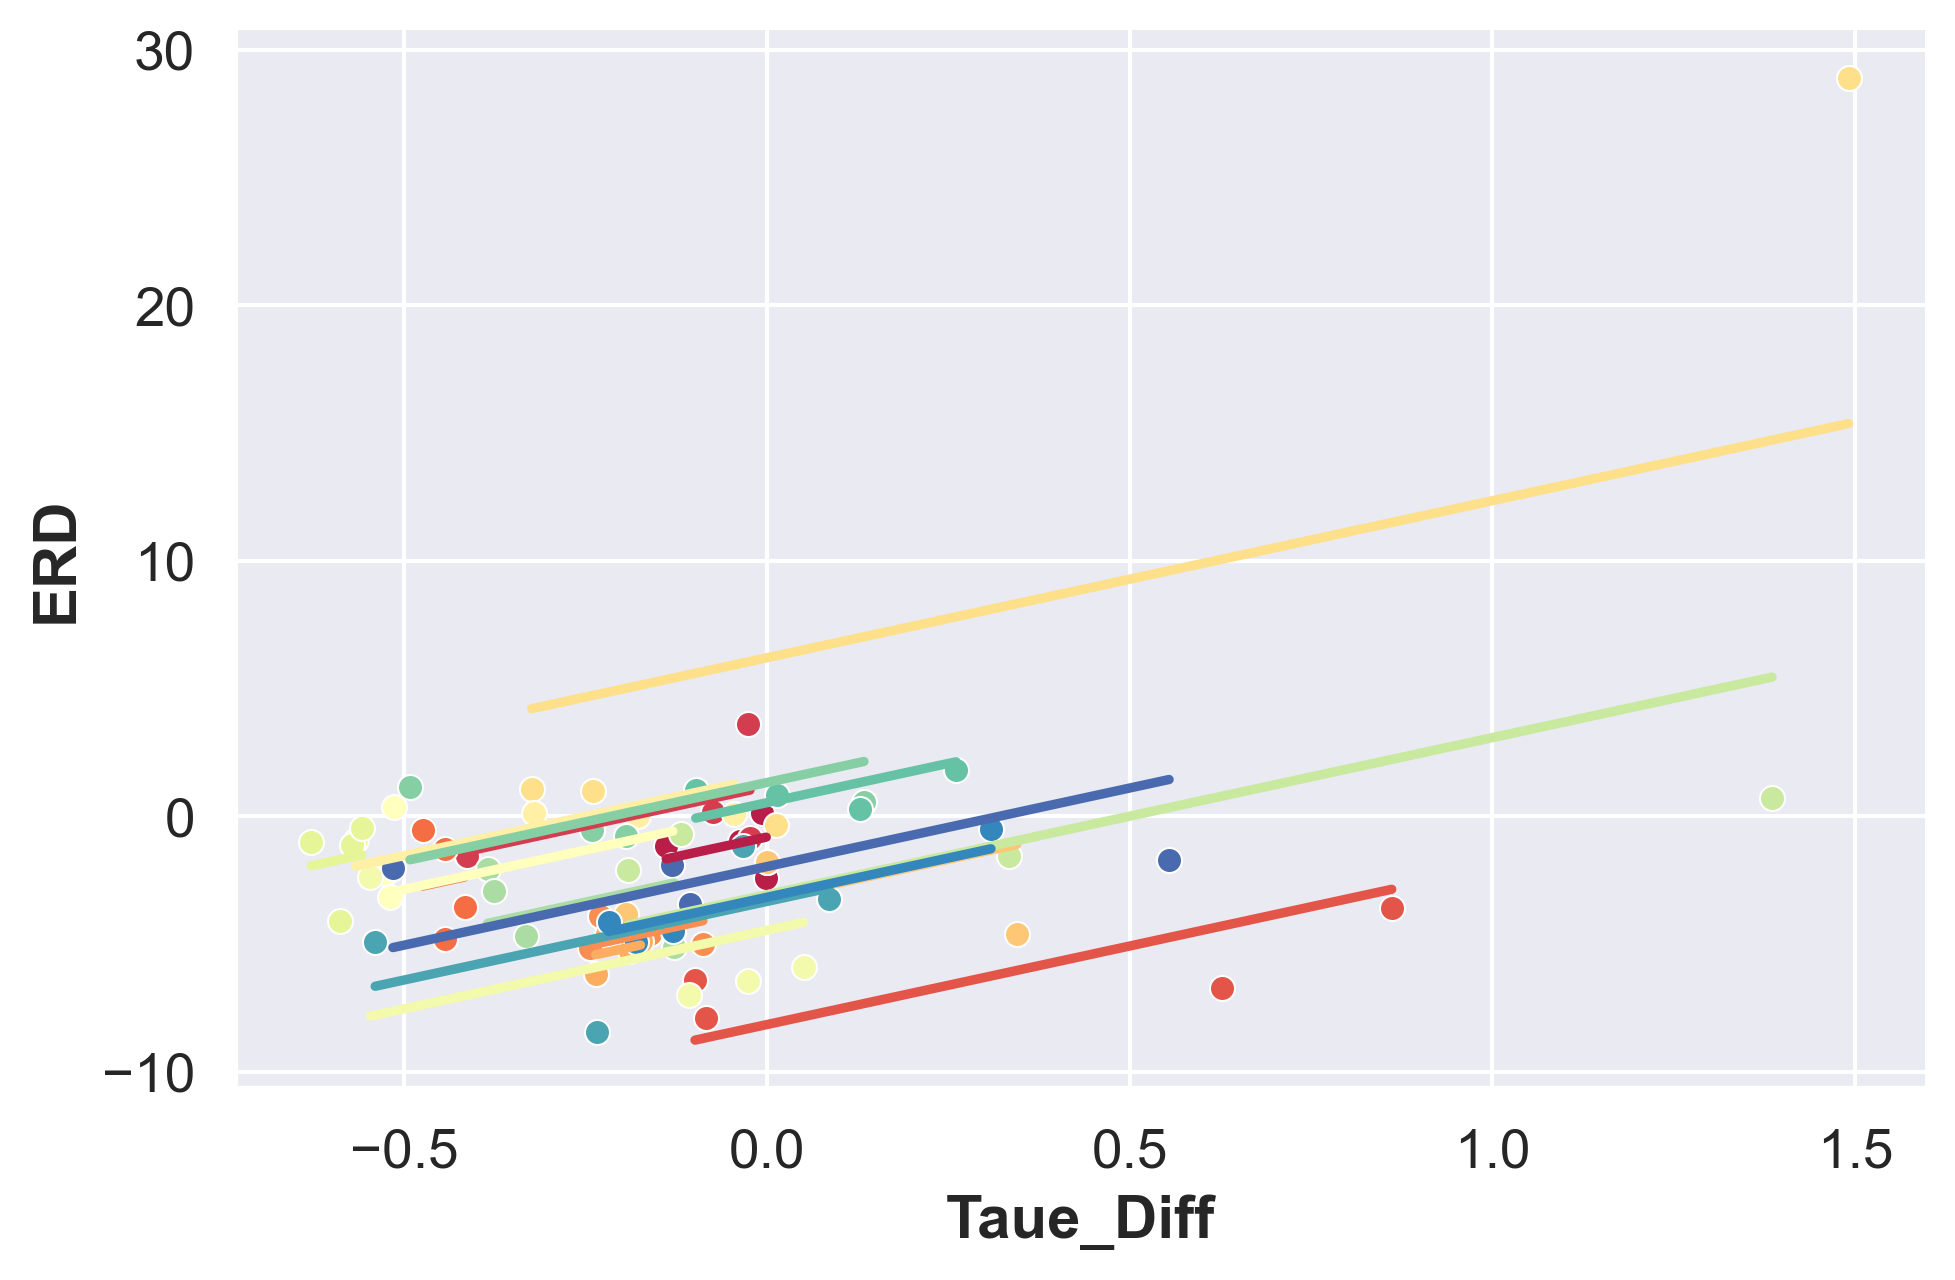

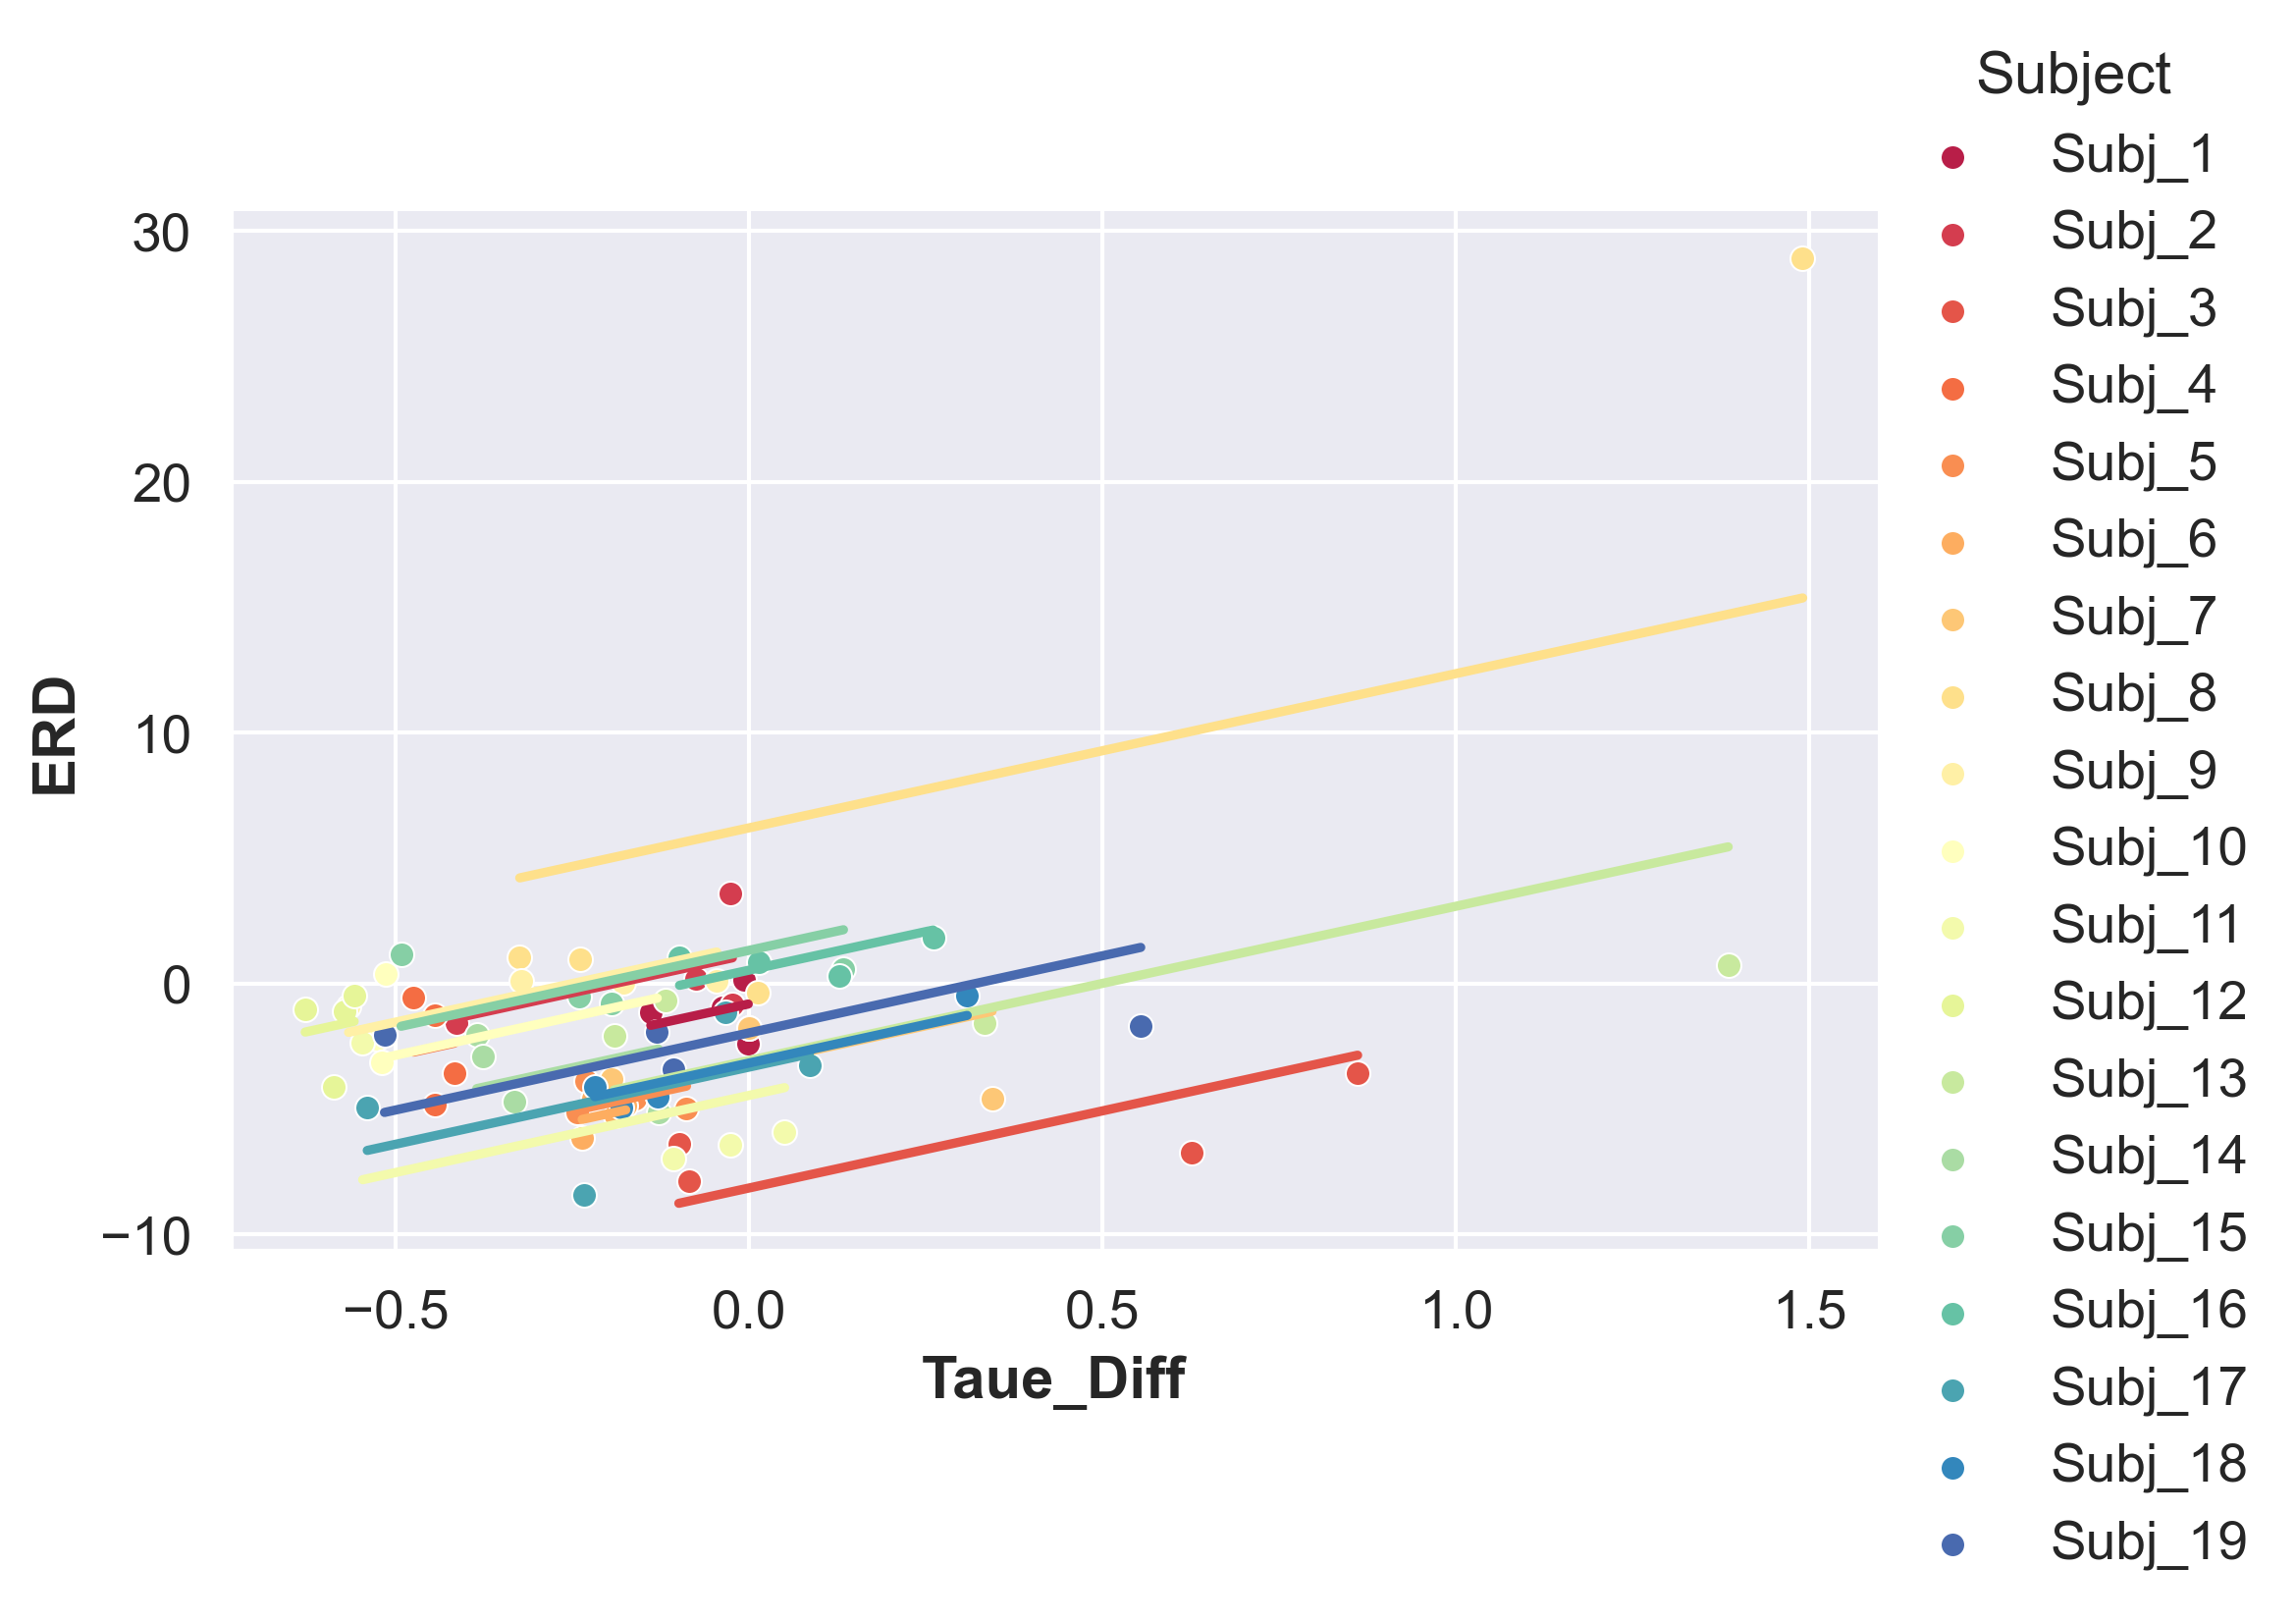

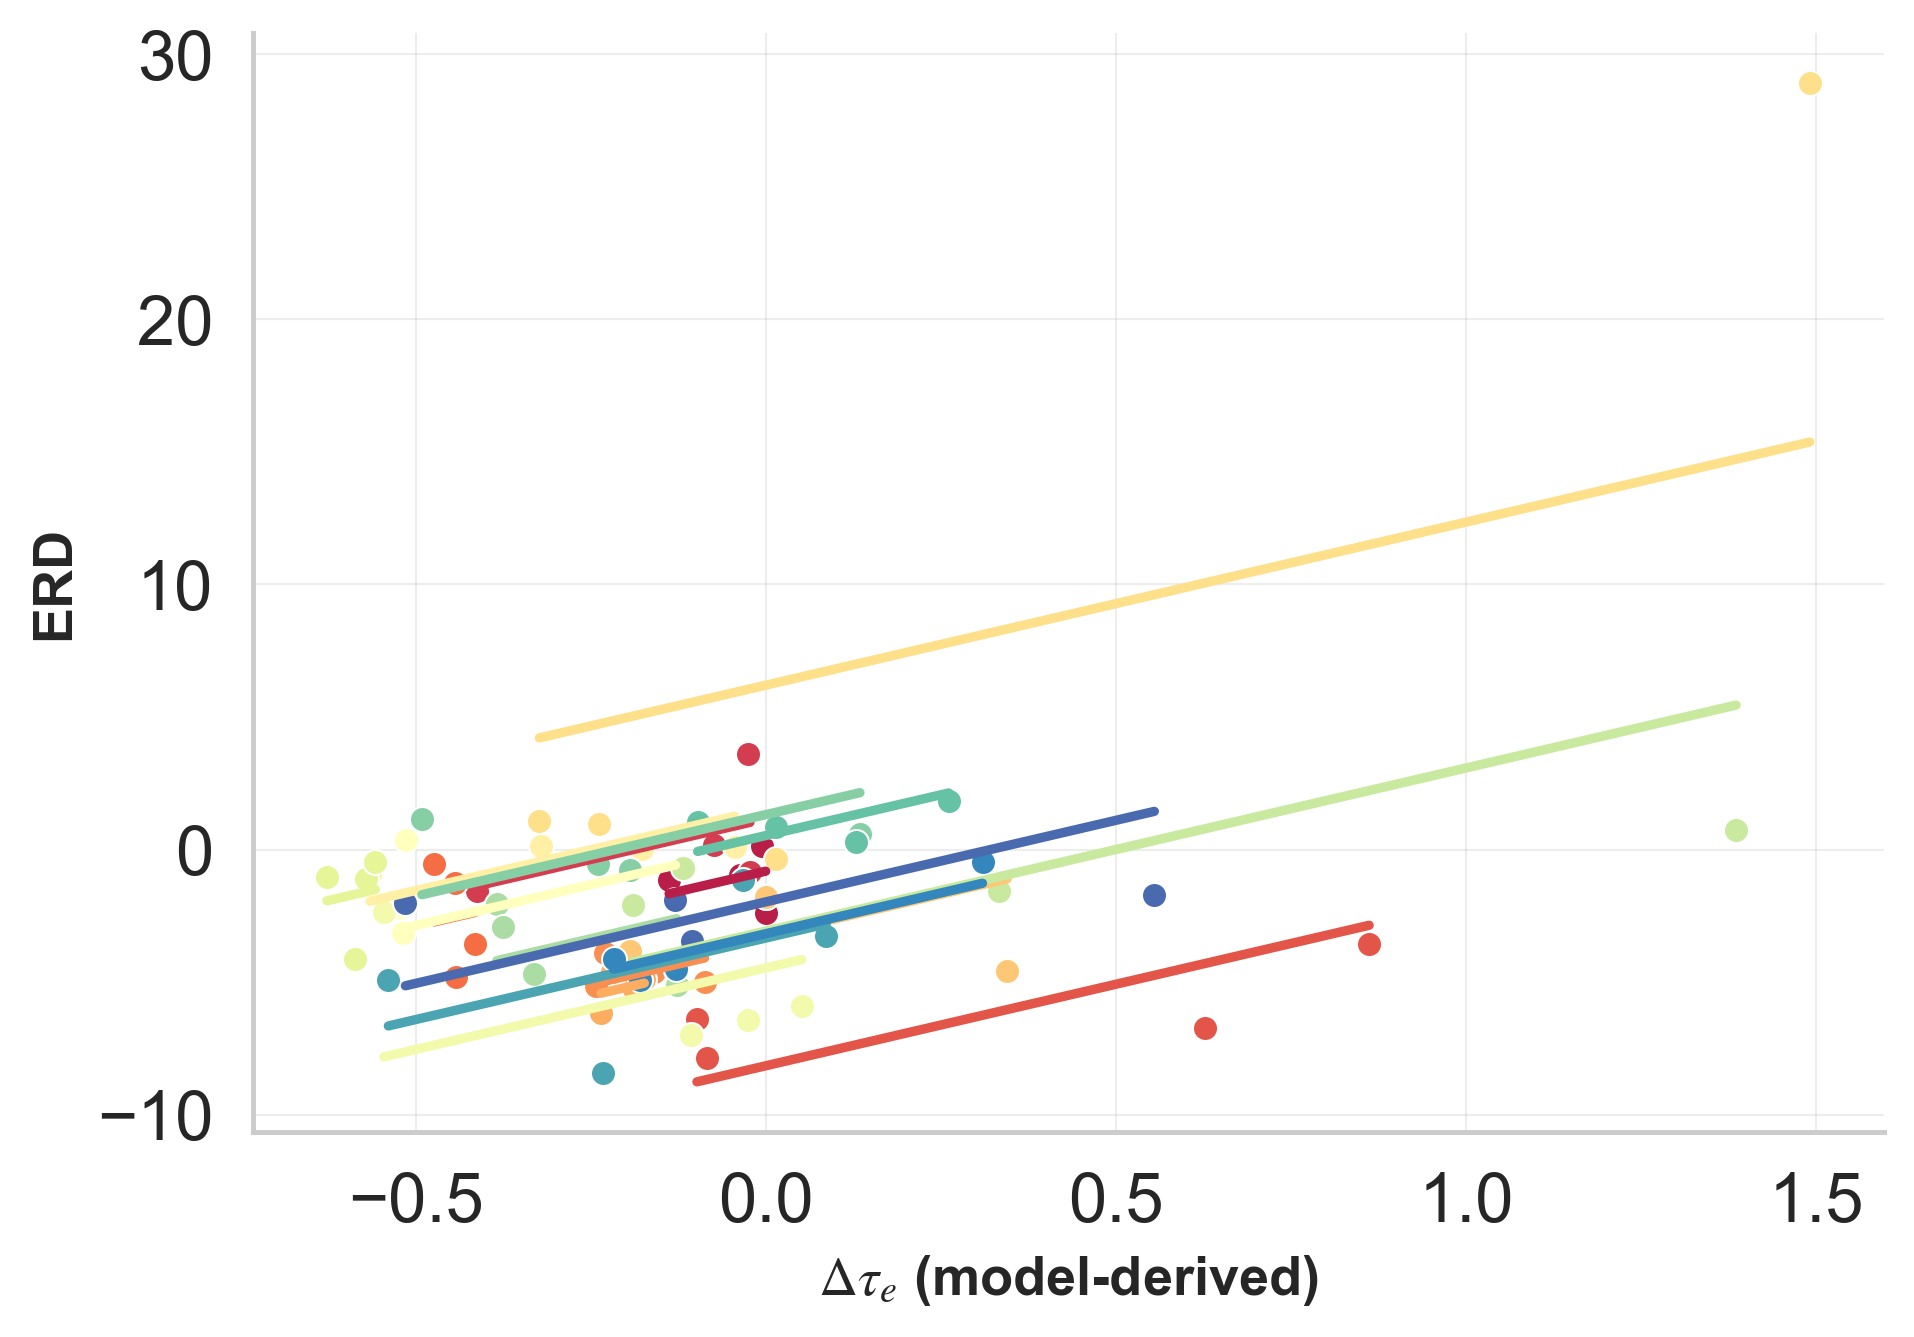

In [62]:
roi = 58  # Left superiorparietal
df_roi = df_long[df_long["ROI"] == roi]

# Theme: publication-oriented (clean, readable, neutral)
sns.set_theme(
    style="whitegrid",
    font_scale=1.5,
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.labelweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Repeated-measures correlation plot
g = pg.plot_rm_corr(
    data=df_roi,
    x="Taue_Diff",
    y="ERD",
    subject="Subject",
    legend=False,
    kwargs_facetgrid=dict(
        height=4.8,
        aspect=1.4,
        palette="Spectral"
    )
)

ax = g.ax

ax.set_xlabel(r"$\Delta \tau_e$ (model-derived)", fontsize=13)
ax.set_ylabel("ERD", fontsize=13)

ax.grid(
    True,
    which="major",
    linewidth=0.5,
    alpha=0.35
)

# plt.savefig(f"/Users/apurbadebnath/Desktop/scatter_repeated_measure_taue_erd.png", dpi=400)
plt.tight_layout()
plt.show()


In [67]:
## Checking motor vs non-motor

motor_rois = [32, 33, 44, 45, 48, 49]

motor_rois = np.array([32, 33, 44, 45, 48, 49])

strongest_erd_rois = {}

for s in erd_roi:
    strongest_erd_rois[s] = np.argsort(erd_roi[s])  # ascending = most negative first

from scipy.stats import mannwhitneyu

erd_motor_stats = {}

for s in erd_roi:
    erd_motor = erd_roi[s][motor_rois]
    erd_nonmotor = np.delete(erd_roi[s], motor_rois)

    U, p = mannwhitneyu(erd_motor, erd_nonmotor, alternative='less')
    erd_motor_stats[s] = {'U': U, 'p': p}

    print(f"Session {s}: motor ERD more negative than non-motor? p = {p:.5f}")

Session 1: motor ERD more negative than non-motor? p = 0.01441
Session 2: motor ERD more negative than non-motor? p = 0.00701
Session 3: motor ERD more negative than non-motor? p = 0.00654
Session 4: motor ERD more negative than non-motor? p = 0.02567


## Figure

In [68]:
# ERD vs delta taue scatter plot
def plot_erd_taue_scatter(erd, dtaue, motor_rois, session, rho, p):
    plt.figure(figsize=(4,4), dpi=300)

    all_rois = np.arange(len(erd))
    nonmotor = np.setdiff1d(all_rois, motor_rois)

    # Non-motor ROIs
    plt.scatter(
        erd[nonmotor],
        dtaue[nonmotor],
        color='lightgray',
        s=35,
        alpha=0.8,
        
        label='Non-motor ROIs'
    )

    # Motor ROIs
    plt.scatter(
        erd[motor_rois],
        dtaue[motor_rois],
        color='crimson',
        s=55,
        edgecolor='black',
        label='Motor ROIs'
    )

    plt.axhline(0, linestyle='--', linewidth=0.8, color='black')
    plt.axvline(0, linestyle='--', linewidth=0.8, color='black')

    #remove grid lines
    plt.grid(False)

    plt.xlabel('ERD (α–β band, % change)', fontsize=11)
    plt.ylabel('$Δτ_e (MI/RS-1)$', fontsize=11)

    plt.title(f'Session {session}', fontsize=12)

    plt.tight_layout()
    # plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_taue_motor_non_motor.png", dpi=600)
    plt.show()


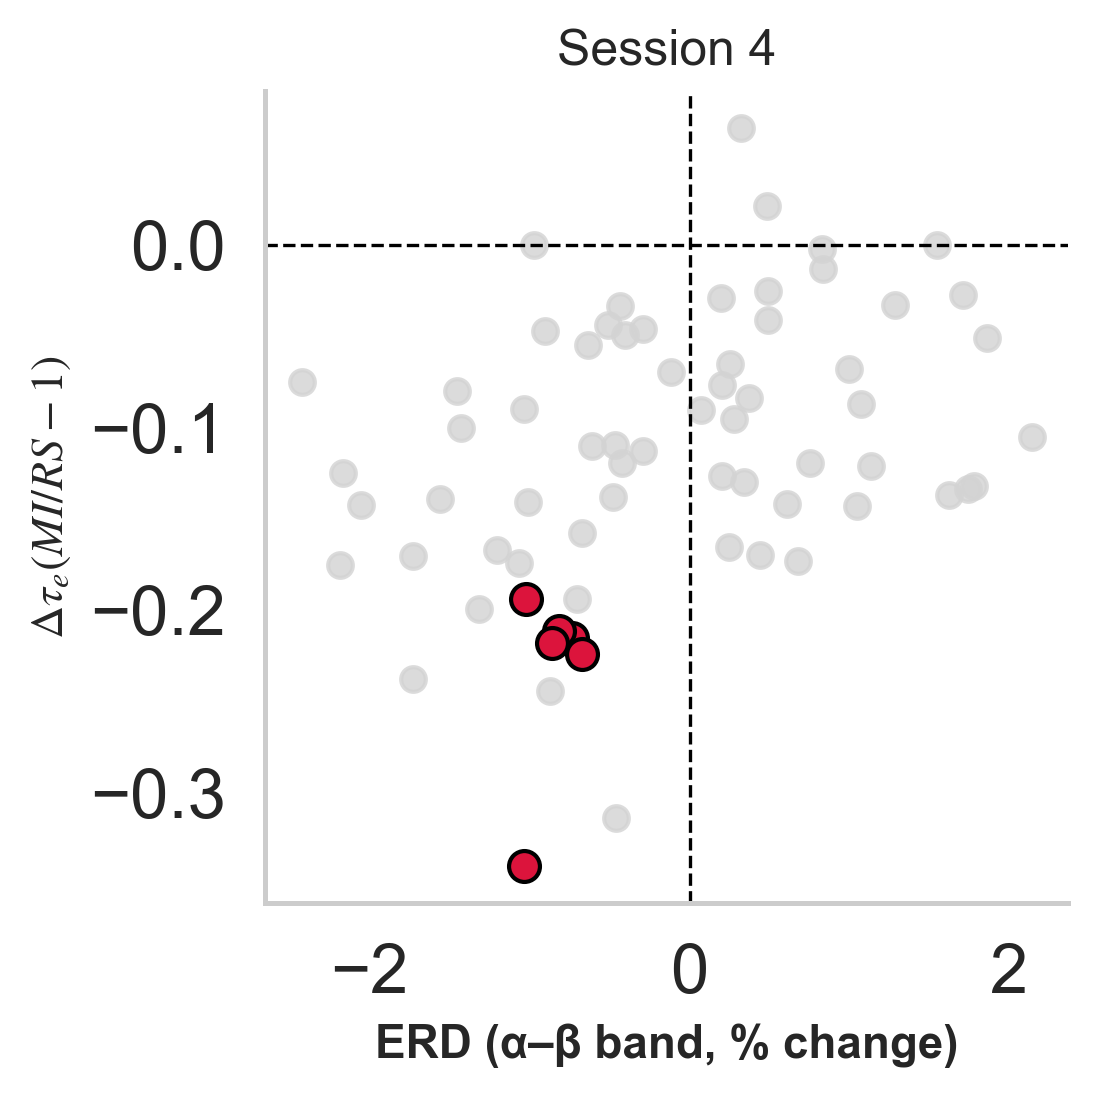

In [69]:
plot_erd_taue_scatter(
    erd_roi[4],
    delta_taue_roi[4],
    motor_rois,
    session=4,
    rho=0.485,
    p=0.0001
)



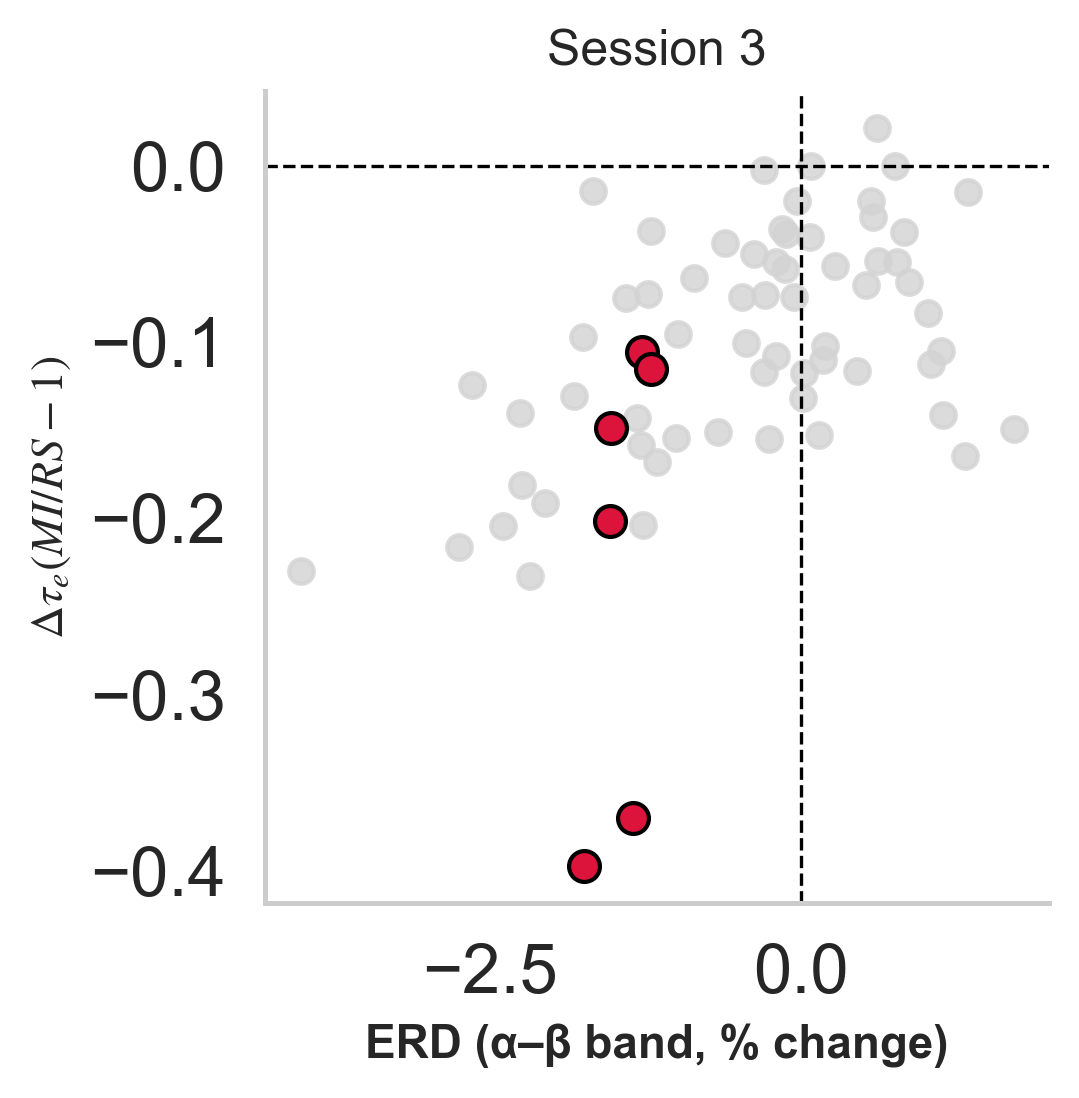

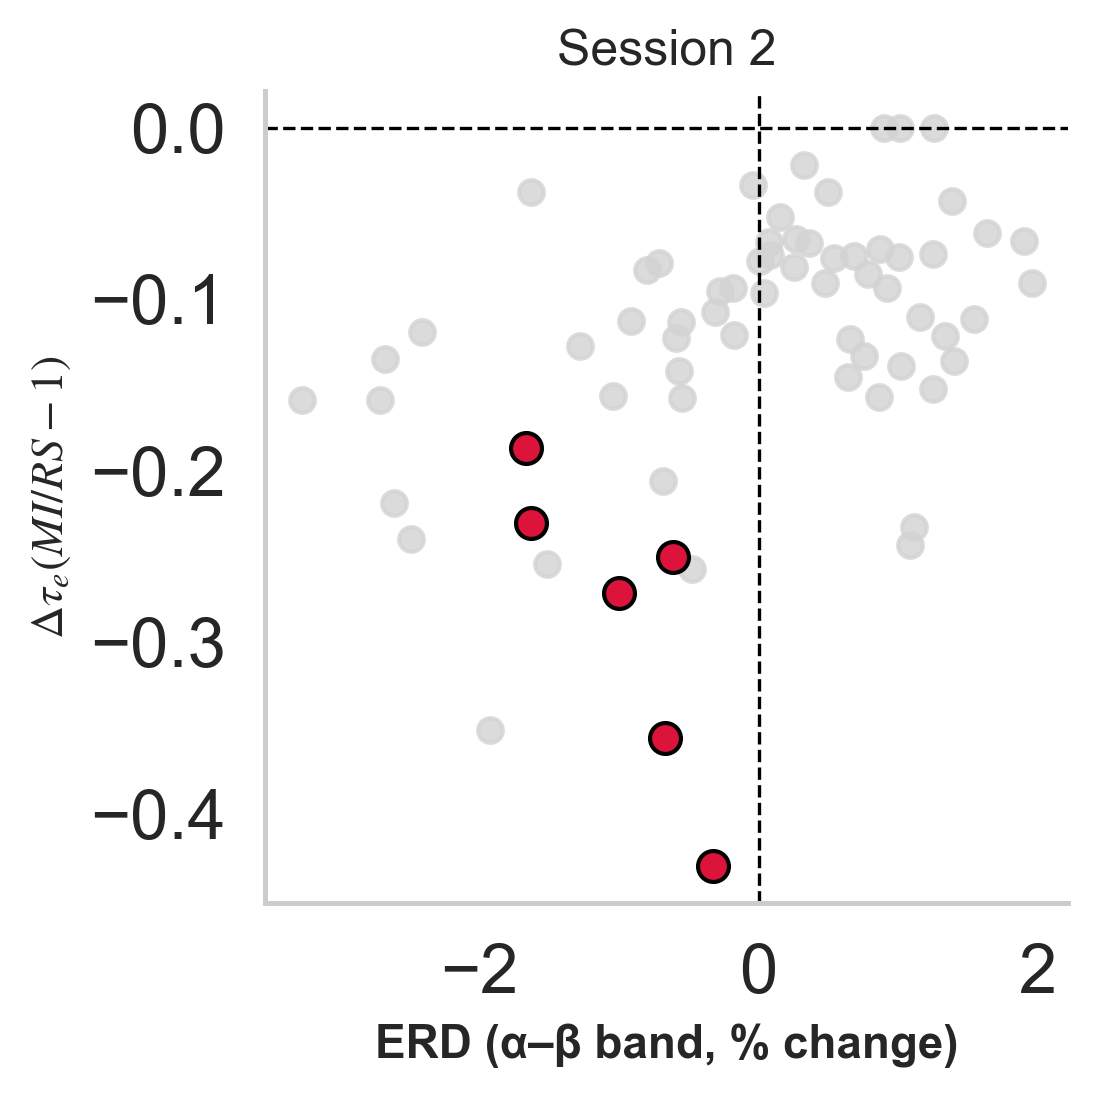

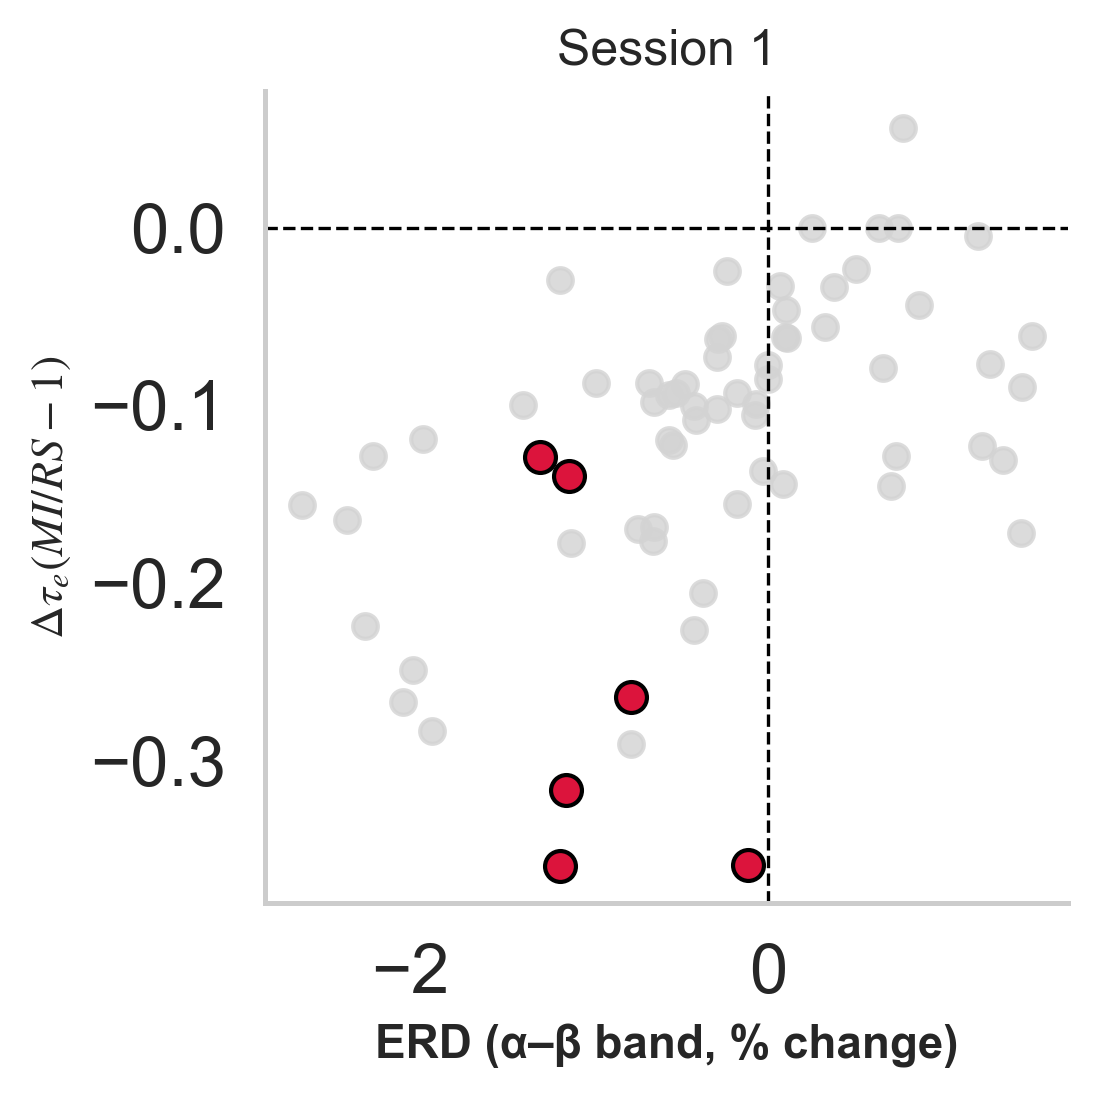

In [70]:
plot_erd_taue_scatter(
    erd_roi[3],
    delta_taue_roi[3],
    motor_rois,
    session=3,
    rho=0.485,
    p=0.0001
)


plot_erd_taue_scatter(
    erd_roi[2],
    delta_taue_roi[2],
    motor_rois,
    session=2,
    rho=0.485,
    p=0.0001
)

plot_erd_taue_scatter(
    erd_roi[1],
    delta_taue_roi[1],
    motor_rois,
    session=1,
    rho=0.485,
    p=0.0001
)


In [229]:
# def plot_motor_vs_nonmotor_erd(erd, motor_rois, session):
#     motor = erd[motor_rois]
#     nonmotor = np.delete(erd, motor_rois)

#     plt.figure(figsize=(3,3), dpi=300)
#     plt.boxplot(
#         [motor, nonmotor],
#         labels=['Motor', 'Non-motor'],
#         widths=0.6,
#         showfliers=False,
#         #box color
#     )

#     plt.ylabel('ERD (α–β band, % change)', fontsize=11)
#     plt.title(f'Session {session}', fontsize=12)
#     plt.axhline(0, linestyle='--', color='black', linewidth=0.8)

#     plt.tight_layout()
#     plt.show()


def plot_motor_vs_nonmotor_erd(erd, motor_rois, session):
    motor = erd[motor_rois]
    nonmotor = np.delete(erd, motor_rois)

    plt.figure(figsize=(3,3), dpi=300)

    bp = plt.boxplot(
        [motor, nonmotor],
        labels=['Motor', 'Non-motor'],
        widths=0.6,
        showfliers=False,
        patch_artist=True  # 
    )

    # Set box colors
    colors = ['crimson', "lightgray"]  # red, pale white
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        # box.set_edgecolor('black')
        # box.set_linewidth(1.2)

    # Style other elements
    # for whisker in bp['whiskers']:
    #     whisker.set_color('black')
    #     whisker.set_linewidth(1.0)

    # for cap in bp['caps']:
    #     cap.set_color('black')
    #     cap.set_linewidth(1.0)

    # for median in bp['medians']:
    #     median.set_color('yellow')
    #     median.set_linewidth(1.5)

    plt.ylabel('ERD (α–β band, % change)', fontsize=11)
    plt.title(f'Session {session}', fontsize=12)
    plt.axhline(0, linestyle='--', color='black', linewidth=0.8)

    plt.tight_layout()
    # plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_motor_non_motor.png", dpi=600)
    plt.show()


In [230]:
motor_rois

array([32, 33, 44, 45, 48, 49])

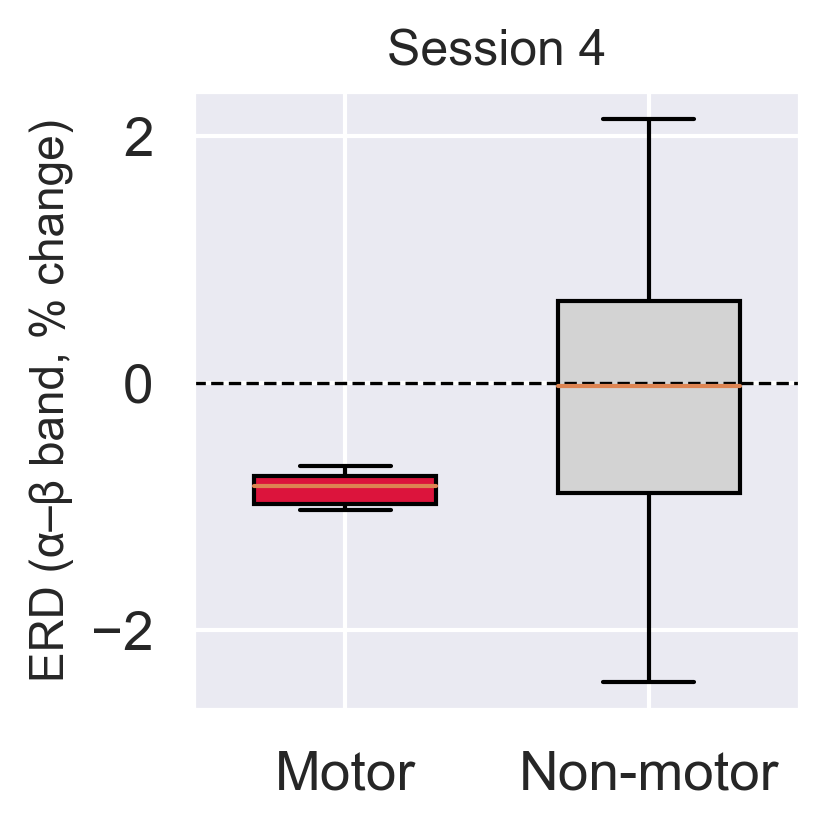

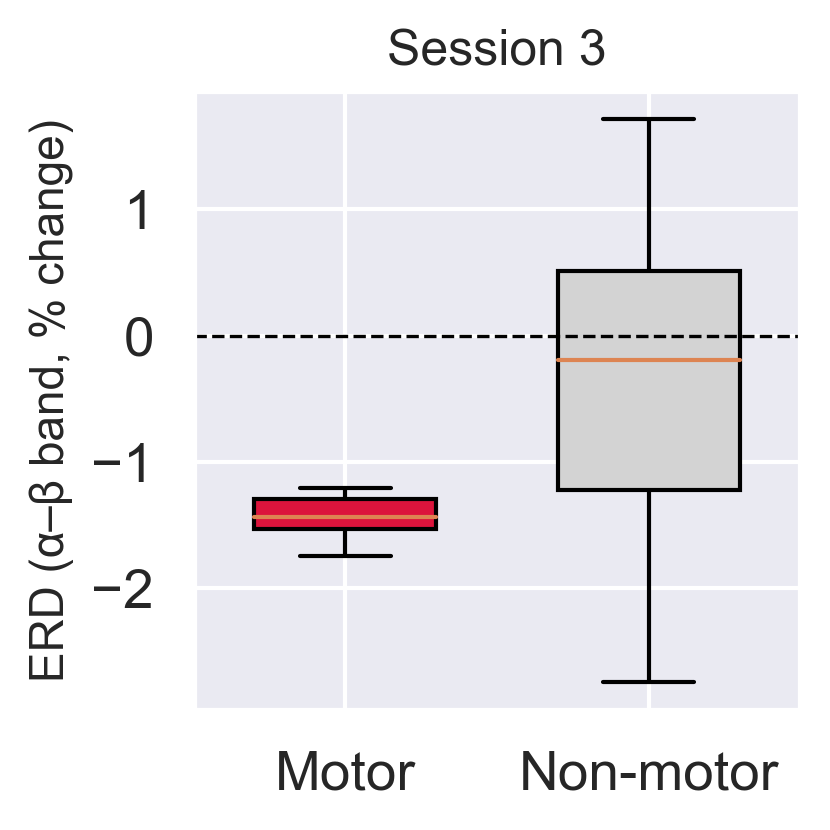

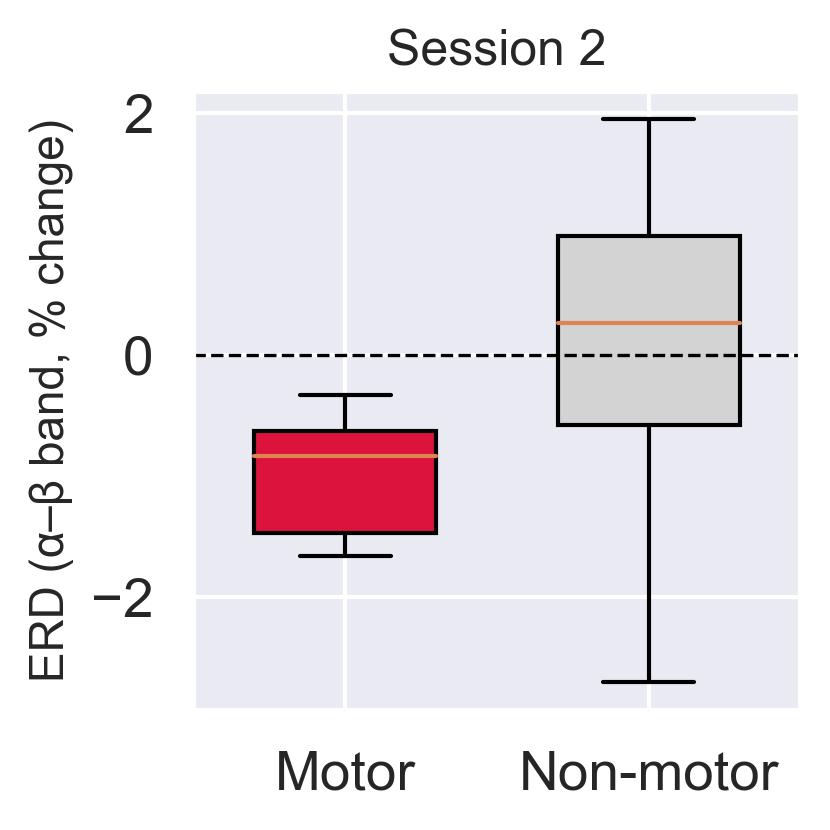

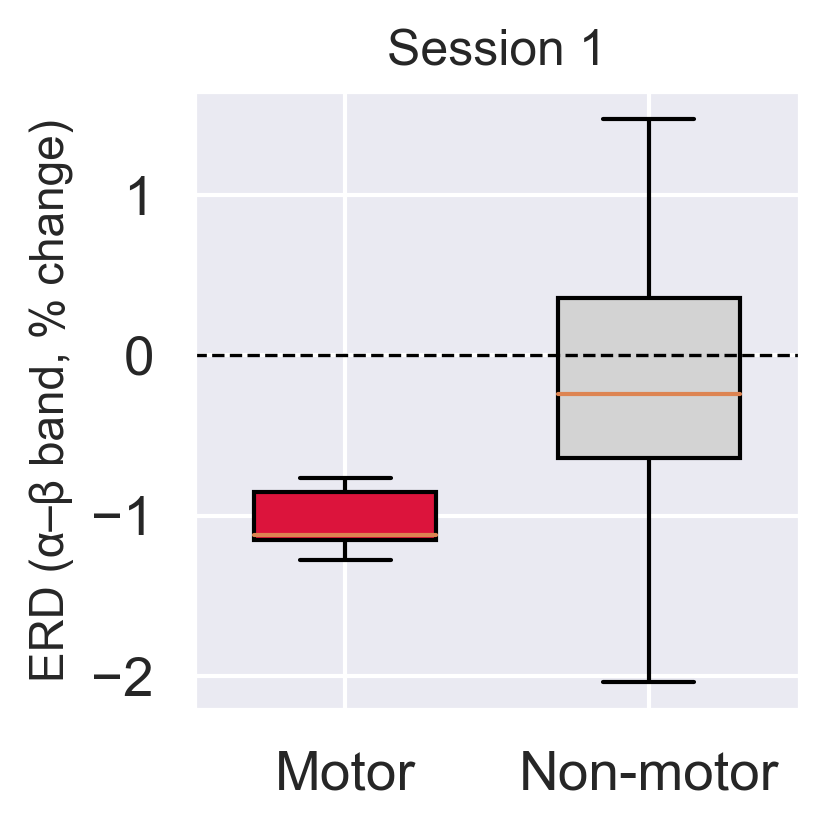

In [231]:
## plot for all 
plot_motor_vs_nonmotor_erd(erd_roi[4], motor_rois, session=4)

plot_motor_vs_nonmotor_erd(erd_roi[3], motor_rois, session=3)
plot_motor_vs_nonmotor_erd(erd_roi[2], motor_rois, session=2)
plot_motor_vs_nonmotor_erd(erd_roi[1], motor_rois, session=1) 



In [71]:
# ## subject level motor bias across sessions
# def plot_motor_bias_across_sessions(motor_bias):
#     sessions = sorted(motor_bias.keys())
#     data = [motor_bias[s] for s in sessions]

#     plt.figure(figsize=(3,3), dpi=300)
#     plt.boxplot(data, labels=[f"S{s}" for s in sessions], showfliers=False)

#     plt.axhline(0, linestyle='--', color='black', linewidth=0.8)
#     plt.ylabel('Motor − Non-motor ERD', fontsize=11)
#     plt.title('Subject-level Motor Bias Across Sessions', fontsize=12)

#     plt.tight_layout()
#     plt.show()


In [72]:
# plot_motor_bias_across_sessions(motor_bias)


## G_ei

In [365]:
# shape: (19, 68)
delta_gei = {} 
for s in range(1, 5):
    gei_mi = x_mi_all[s][:, 0, :] / x_rest_all[s][:, 0, :] - 1
    delta_gei[s] = gei_mi.T

#for each region
delta_gei_roi = {}
for s in delta_gei:
    delta_gei_roi[s] = np.median(delta_gei[s], axis=0)

In [366]:
delta_gei[4]

array([[-9.84820575e-01, -9.98510358e-01, -3.23052274e-01, ...,
        -5.23464127e-01, -9.52403236e-01, -5.52631735e-01],
       [-5.22490127e-01,  2.04504779e+01, -4.56562367e-02, ...,
         4.99000000e+02, -7.64770698e-02, -1.08147633e-01],
       [-9.95665126e-01, -3.55038060e-02,  1.71572089e-01, ...,
        -9.96200487e-01,  0.00000000e+00,  5.36868756e+02],
       ...,
       [-9.29303002e-02,  1.75053186e+02,  3.71167988e+02, ...,
        -2.20693008e-01,  4.70288269e-01,  1.63014408e+02],
       [ 1.11261171e-01,  2.37768936e+00, -6.23927118e-01, ...,
        -9.68795290e-01, -2.34095310e-01, -5.25228214e-01],
       [-1.31605262e-01, -9.95600401e-01,  0.00000000e+00, ...,
         9.73754368e-02, -5.74019573e-02, -9.96466124e-01]])

In [367]:
#Find the regions that shows positive and negative change in GEI
negative_gei_regions = {}
positive_gei_regions = {}
for s in delta_gei_roi:
    # print(f"Session {s}:")
    idx_pos = np.where(delta_gei_roi[s] >= 0)[0]
    idx_neg = np.where(delta_gei_roi[s] < 0)[0]
    region_pos = [all_regions[i].strip(" '' ") for i in idx_pos]
    region_neg = [all_regions[i].strip(" '' ") for i in idx_neg]
    negative_gei_regions[s] = region_neg
    positive_gei_regions[s] = region_pos


In [368]:
np.array(negative_gei_regions[3])

array(['caudalanteriorcingulate L', 'caudalanteriorcingulate R',
       'caudalmiddlefrontal L', 'caudalmiddlefrontal R', 'frontalpole L',
       'frontalpole R', 'fusiform L', 'inferiortemporal L', 'insula L',
       'lateralorbitofrontal R', 'medialorbitofrontal L',
       'middletemporal L', 'middletemporal R', 'parahippocampal L',
       'parsopercularis L', 'parsopercularis R', 'parsorbitalis R',
       'parstriangularis L', 'parstriangularis R', 'posteriorcingulate L',
       'precentral L', 'precuneus R', 'rostralanteriorcingulate L',
       'rostralanteriorcingulate R', 'rostralmiddlefrontal L',
       'superiortemporal L', 'superiortemporal R', 'transversetemporal L',
       'transversetemporal R'], dtype='<U26')

In [369]:
## correlation between ERD and delta gei
erd_gei_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_gei_roi[s])
    erd_gei_corr[s] = {"rho": rho, "p": p}

for s in erd_gei_corr:
    print(f"Session {s}: Spearman rho={erd_gei_corr[s]['rho']:.3f}, "
          f"p={erd_gei_corr[s]['p']:.8f}")



Session 1: Spearman rho=-0.486, p=0.00002655
Session 2: Spearman rho=-0.476, p=0.00004098
Session 3: Spearman rho=-0.425, p=0.00030184
Session 4: Spearman rho=-0.185, p=0.13025502


In [372]:
n_regions = 68
n_subjects = 19
sessions = [1, 2, 3, 4]

records = []

for sess in sessions:
    mi_data = x_mi_all[sess][:, 0, :]       # (68, 19)
    rest_data = x_rest_all[sess][:, 0, :]   # (68, 19)
    erd_data = erd_ab[sess]                 # (19, 68)

    for subj_idx in range(n_subjects):
        row = {
            "Subject": f"Subj_{subj_idx+1}",
            "Session": sess
        }

        for roi in range(n_regions):
            row[f"ERD_ROI{roi}"] = erd_data[subj_idx, roi]
            row[f"gei_Diff_ROI{roi}"] = (
                mi_data[roi, subj_idx] / rest_data[roi, subj_idx] - 1
            )

        records.append(row)

df_all = pd.DataFrame(records)

print(f"Dataframe prepared. Shape: {df_all.shape} "
      f"(Rows: {n_subjects*len(sessions)}, Cols: ERD + gei)")


Dataframe prepared. Shape: (76, 138) (Rows: 76, Cols: ERD + gei)


In [373]:
df_all

,Subject,Session,ERD_ROI0,gei_Diff_ROI0,ERD_ROI1,gei_Diff_ROI1,ERD_ROI2,gei_Diff_ROI2,ERD_ROI3,gei_Diff_ROI3,...,ERD_ROI63,gei_Diff_ROI63,ERD_ROI64,gei_Diff_ROI64,ERD_ROI65,gei_Diff_ROI65,ERD_ROI66,gei_Diff_ROI66,ERD_ROI67,gei_Diff_ROI67
0,Subj_1,1,1.237586,-0.957272,-0.596909,-0.200560,0.069754,-0.078435,-0.163784,-0.020828,...,-1.456133,-0.176248,1.572769,0.012436,2.307161,-0.138860,0.745937,-0.996416,-0.398687,-0.365938
1,Subj_2,1,0.992611,-0.005751,-0.609178,0.241676,0.239483,-0.974409,1.043304,-0.964273,...,1.022276,-0.997500,-0.598077,-0.371234,1.316147,0.000000,0.348638,-0.413810,-0.254057,-0.997075
2,Subj_3,1,-3.427769,17.920464,-0.926492,0.000000,0.849447,0.195520,-1.651089,302.448611,...,-2.925416,367.563049,0.039456,0.166075,1.259191,-0.148379,-3.054757,66.102597,-1.365997,575.172061
3,Subj_4,1,-3.223162,0.000000,-2.159013,0.000000,0.168454,3.565350,-0.068684,15.622300,...,-0.664215,471.128276,-0.100112,173.223677,1.397391,17.178421,-0.717948,0.000000,-0.531054,0.000000
4,Subj_5,1,-2.569079,400.437978,-0.636554,1.540676,-1.004179,209.499554,-1.772997,201.497714,...,-0.765646,-0.995235,-2.821851,287.903360,0.930814,0.231087,-2.537175,263.661182,-2.696340,242.751368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Subj_15,4,0.478667,-0.212610,-0.719593,-0.370362,1.292121,-0.481296,1.724685,-0.248597,...,0.531040,-0.284064,4.283520,-0.083199,0.381160,-0.320675,0.973372,-0.964099,0.218502,-0.066472
72,Subj_16,4,-0.068933,-0.241848,0.854284,-0.284785,0.351603,-0.055692,-0.068169,1.534230,...,-0.053034,-0.220699,6.608638,-0.099226,5.167488,-0.055318,0.383846,0.088199,0.660496,-0.101032
73,Subj_17,4,-0.084093,-0.092930,-1.008271,175.053186,2.513411,371.167988,0.777956,-0.957862,...,-0.458432,-0.699120,-0.231153,0.245348,1.023949,-0.220693,-0.964861,0.470288,-1.862818,163.014408
74,Subj_18,4,0.169007,0.111261,-3.979546,2.377689,0.165974,-0.623927,0.207828,-0.996118,...,-3.060923,-0.863175,2.059212,-0.462478,0.752669,-0.968795,0.099152,-0.234095,-2.603941,-0.525228


In [374]:
##repeated measure correlation

import pandas as pd
import pingouin as pg

long_records = []

for roi in range(n_regions):
    for _, row in df_all.iterrows():
        long_records.append({
            "Subject": row["Subject"],
            "Session": row["Session"],
            "ROI": roi,
            "ERD": row[f"ERD_ROI{roi}"],
            "gei_Diff": row[f"gei_Diff_ROI{roi}"]
        })

df_long = pd.DataFrame(long_records)


In [375]:
rmcorr_results = []

for roi in range(n_regions):
    df_roi = df_long[df_long["ROI"] == roi]

    rmc = pg.rm_corr(
        data=df_roi,
        x="gei_Diff",
        y="ERD",
        subject="Subject"
    )

    rmcorr_results.append({
        "ROI": roi,
        "r": rmc["r"].values[0],
        "p_uncorrected": rmc["pval"].values[0]
    })

df_rmcorr = pd.DataFrame(rmcorr_results)

from statsmodels.stats.multitest import fdrcorrection

rej, p_fdr = fdrcorrection(df_rmcorr["p_uncorrected"], alpha=0.05)

df_rmcorr["p_fdr"] = p_fdr
df_rmcorr["significant"] = rej


In [376]:
# Find regions with significant repeated measures correlation and store in a list
significant_regions = df_rmcorr[df_rmcorr["significant"]].sort_values("p_fdr")
significant_regions_list = significant_regions["ROI"].tolist()
significant_regions_list

[]

In [332]:
#Find the regions coresponding to +ve ERD for taue
regions_list = {}
for s in erd_roi:
    # print(f"Session {s}:")
    idx = np.where(erd_roi[s] > 0)[0]
    region = [all_regions[i].strip(" '' ") for i in idx]
    regions_list[s] = region
   
len(regions_list[4])

32

## G_ii

In [218]:
# shape: (19, 68)
delta_gii = {} 
for s in range(1, 5):
    gii_mi = x_mi_all[s][:, 1, :] / x_rest_all[s][:, 1, :] - 1
    delta_gii[s] = gii_mi.T

#for each region
delta_gii_roi = {}
for s in delta_gii:
    delta_gii_roi[s] = np.median(delta_gii[s], axis=0)

In [337]:
# delta_gii_roi

In [219]:
## correlation between ERD and delta gii
erd_gii_corr = {}

for s in erd_roi:
    rho, p = spearmanr(erd_roi[s], delta_gii_roi[s])
    erd_gii_corr[s] = {"rho": rho, "p": p}

for s in erd_gii_corr:
    print(f"Session {s}: Spearman rho={erd_gii_corr[s]['rho']:.3f}, "
          f"p={erd_gii_corr[s]['p']:.8f}")



Session 1: Spearman rho=-0.257, p=0.03464806
Session 2: Spearman rho=-0.217, p=0.07595059
Session 3: Spearman rho=-0.251, p=0.03934269
Session 4: Spearman rho=-0.235, p=0.05378024


In [222]:
# ERD vs delta gei scatter plot
def plot_erd_gei_scatter(erd, dgei, motor_rois, session, rho, p):
    plt.figure(figsize=(4,4), dpi=300)

    all_rois = np.arange(len(erd))
    nonmotor = np.setdiff1d(all_rois, motor_rois)

    # Non-motor ROIs
    plt.scatter(
        erd[nonmotor],
        dgei[nonmotor],
        color='lightgray',
        s=35,
        alpha=0.8,
        label='Non-motor ROIs'
    )

    # Motor ROIs
    plt.scatter(
        erd[motor_rois],
        dgei[motor_rois],
        color='crimson',
        s=55,
        edgecolor='black',
        label='Motor ROIs'
    )

    plt.axhline(0, linestyle='--', linewidth=0.8, color='black')
    plt.axvline(0, linestyle='--', linewidth=0.8, color='black')

    plt.xlabel('ERD (α–β band, % change)', fontsize=11)
    plt.ylabel('$Δg_ei (MI/RS-1)$', fontsize=11)

    plt.title(f'Session {session}', fontsize=12)

    # plt.text(
    #     0.02, 0.95,
    #     f"Spearman ρ = {rho:.2f}\np < 0.001",
    #     transform=plt.gca().transAxes,
    #     fontsize=10,
    #     verticalalignment='top'
    # )

    # plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    # plt.savefig(f"/Users/apurbadebnath/Desktop/session_{session}_ERD_gei_motor_non_motor.png", dpi=600)
    plt.show()
